In [55]:
import pandas as pd
import numpy as np


In [56]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [57]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])


In [58]:
df.dropna(inplace=True)

In [59]:
df.shape

(714, 3)

In [60]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [61]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [64]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)


0.6363636363636364

In [65]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6288928012519561)

In [66]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

In [67]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [68]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [69]:
trf.named_transformers_['first'].n_bins_

array([15])

In [70]:
trf.named_transformers_['second'].n_bins_

array([15])

In [71]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [72]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [73]:
output = pd.DataFrame({
    'age':X_train_trf[:,0],
    'age_trf':X_train_trf[:,1],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1],
})


In [74]:
output['age_labels'] = pd.cut(x=X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
314,12.0,9.0,26.250,9.0,"(42.0, 47.0]","(26.0, 26.55]"
850,0.0,11.0,31.275,11.0,"(0.42, 6.0]","(26.55, 31.275]"
553,4.0,0.0,7.225,0.0,"(21.0, 23.0]","(0.0, 7.25]"
489,1.0,7.0,15.900,7.0,"(6.0, 16.0]","(14.454, 18.75]"
617,6.0,7.0,16.100,7.0,"(25.0, 28.0]","(14.454, 18.75]"


In [75]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [76]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6723004694835681)

In [77]:
def discretize(bins,strategy):
  kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
  kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

  trf = ColumnTransformer([
      ('first',kbin_age,[0]),
      ('second',kbin_fare,[1])
  ])

  X_trf = trf.fit_transform(X)
  print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy')))
  plt.figure(figsize=(14,8))
  plt.subplot(1,2,1)
  plt.hist(X['Age'])
  plt.title('Before')
  plt.subplot(1,2,2)
  plt.hist(X_trf[:,0],color='red')
  plt.title("After")
  plt.show()
  plt.figure(figsize=(14,8))
  plt.subplot(1,2,1)
  plt.hist(X['Fare'])
  plt.title('Before')
  plt.subplot(1,2,2)
  plt.hist(X_trf[:,1],color='red')
  plt.title("After")
  plt.show()

0.682140062597809


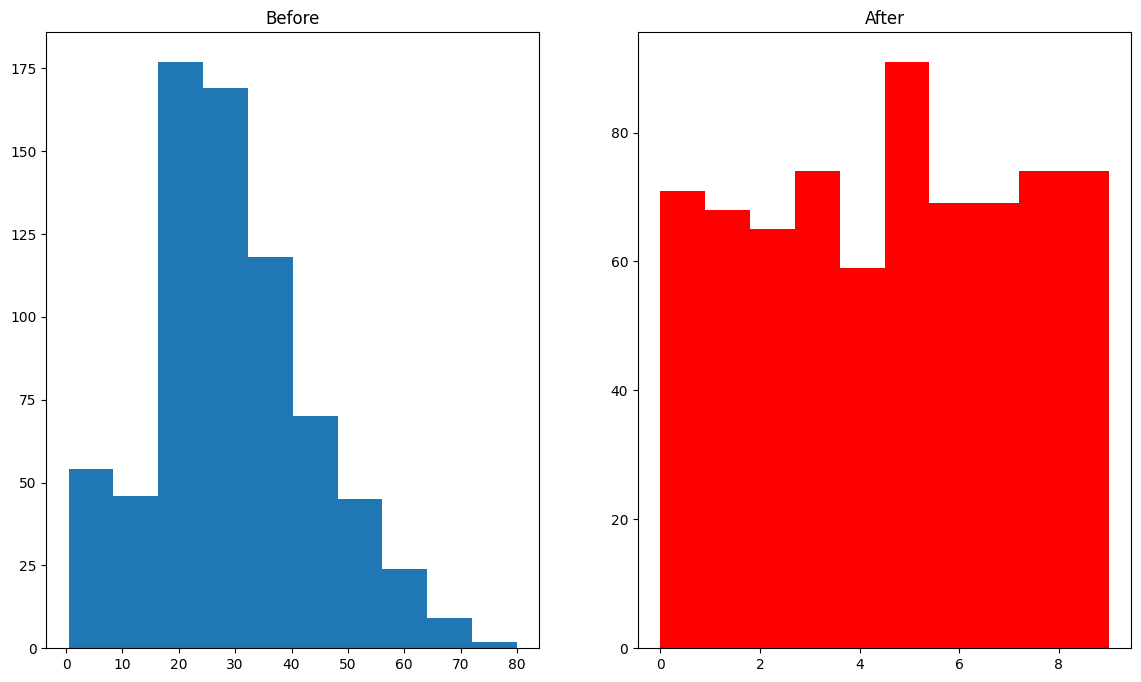

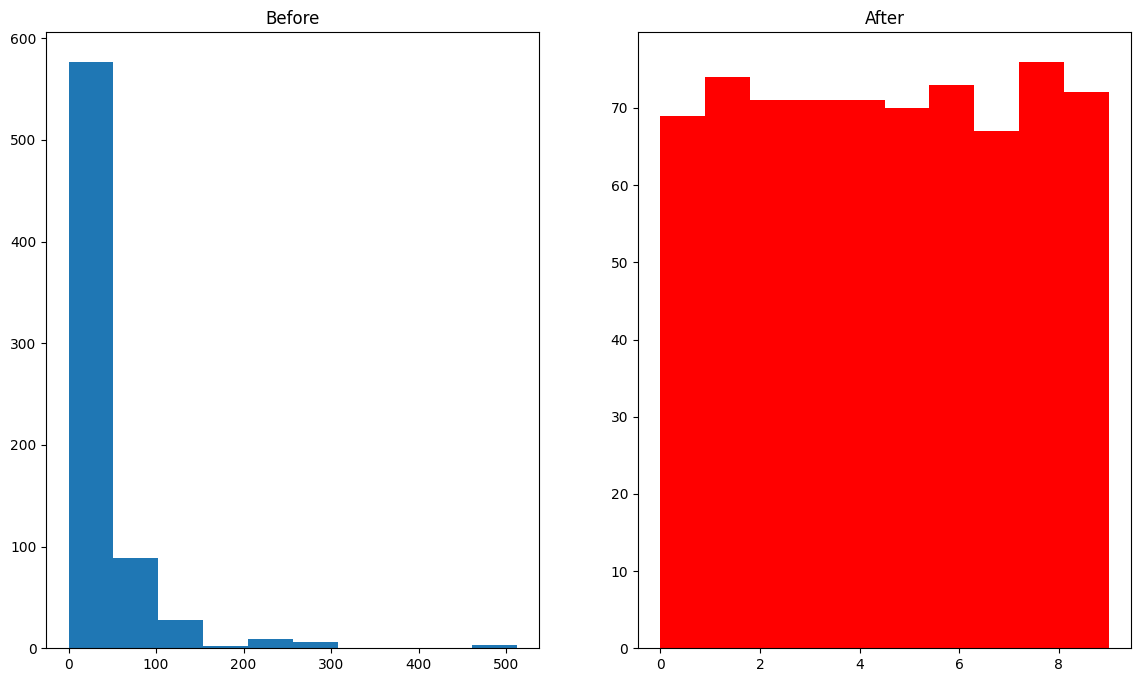

In [78]:
discretize(10,'quantile')

0.6723982785602504


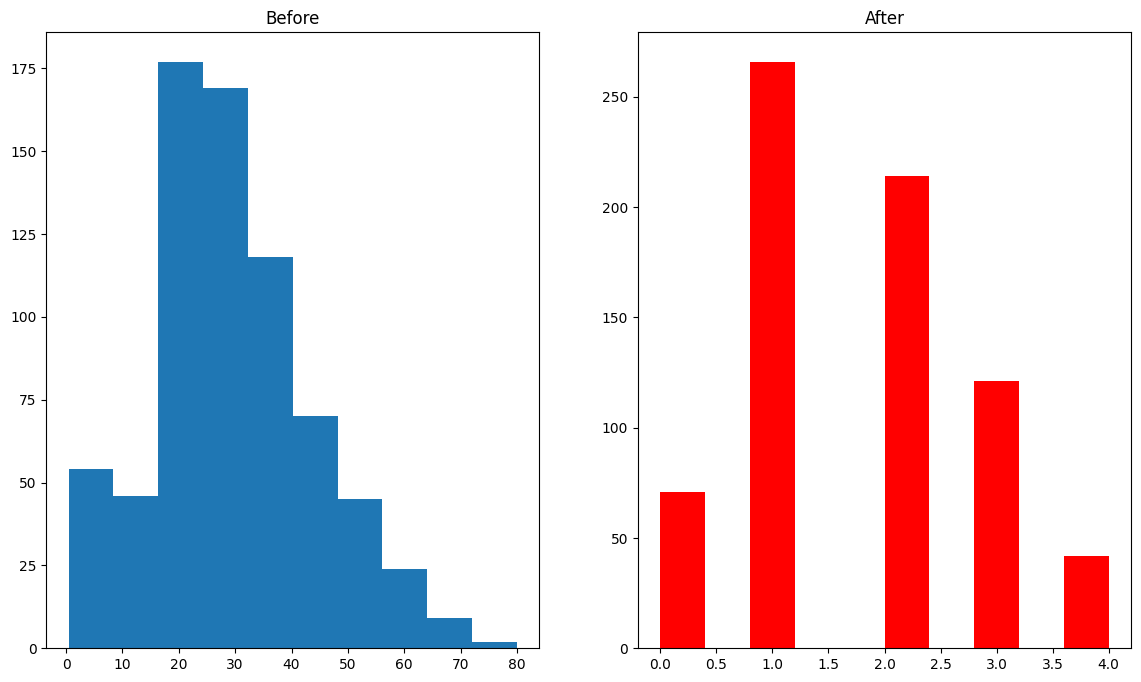

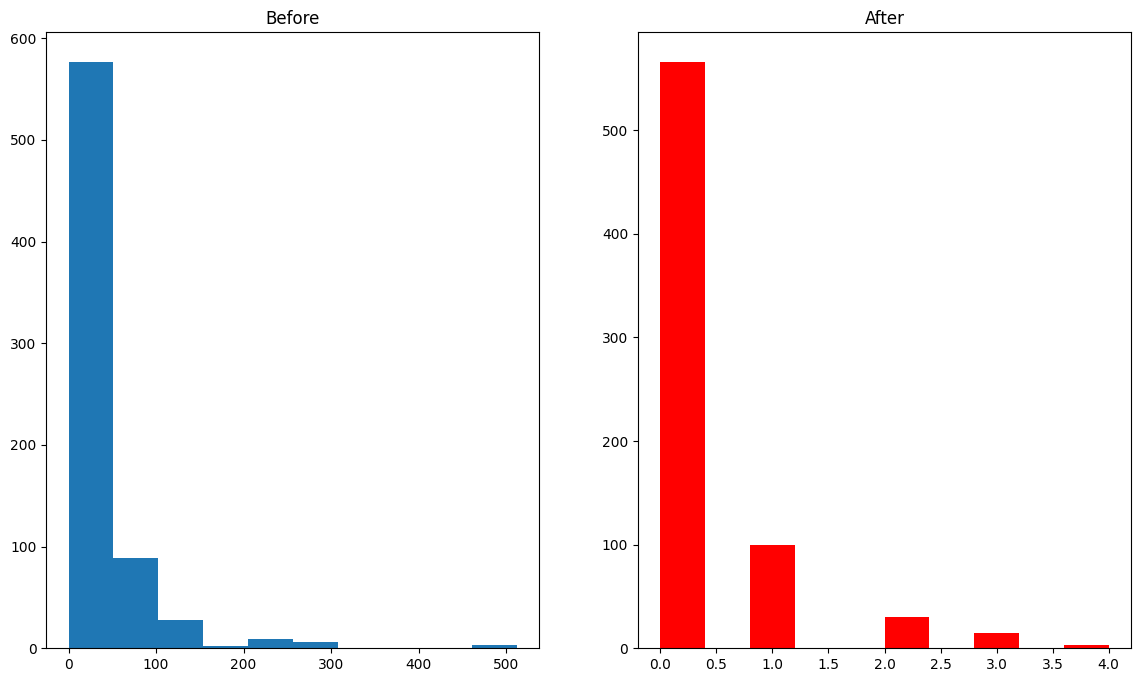

In [79]:
discretize(5,'kmeans')